### BREAST CANCER CLASSIFICATION

#### Importing libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix,classification_report

#### Data loading and preparation

In [2]:
import os
import shutil

source_dir = r"C:\Users\Hima\Downloads\archive"
target_dir = "IDC_fixed"

os.makedirs(os.path.join(target_dir, "0"), exist_ok=True)
os.makedirs(os.path.join(target_dir, "1"), exist_ok=True)

for patient in os.listdir(source_dir)[:10]:
    patient_path = os.path.join(source_dir, patient)
    
    if os.path.isdir(patient_path):
        for label in ["0", "1"]:
            label_path = os.path.join(patient_path, label)
            
            if os.path.exists(label_path):
                for img in os.listdir(label_path):
                    src = os.path.join(label_path, img)
                    dst = os.path.join(target_dir, label, img)
                    shutil.copy(src, dst)

print("Dataset fixed!")

Dataset fixed!


In [3]:
data_dir = "IDC_fixed"

img_size=(50,50)
batch_size=32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,           
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(   
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    seed=42
)

val_data = val_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,               
    seed=42
)

Found 98559 images belonging to 2 classes.
Found 24639 images belonging to 2 classes.


In [4]:
print(train_data.class_indices)

{'0': 0, '1': 1}


#### CancerNet Model

In [5]:
model = Sequential()

# Conv Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(50,50,3)))
model.add(BatchNormalization())   # FIX: Stabilises training
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))  # Binary classification

C:\Users\Hima\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Compile model

In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### Train Model

In [7]:
class_weight = {0: 1.0, 1: 3.5}

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,               
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    steps_per_epoch=len(train_data),    
    validation_steps=len(val_data),     
    class_weight=class_weight,
    callbacks=callbacks                 
)

Epoch 1/25
3080/3080 ━━━━━━━━━━━━━━━━━━━━ 1426s 460ms/step - accuracy: 0.7345 - loss: 0.8770 - val_accuracy: 0.7045 - val_loss: 0.7753 - learning_rate: 1.0000e-04
Epoch 2/25
3080/3080 ━━━━━━━━━━━━━━━━━━━━ 1082s 351ms/step - accuracy: 0.7930 - loss: 0.7343 - val_accuracy: 0.7347 - val_loss: 0.6354 - learning_rate: 1.0000e-04
Epoch 3/25
3080/3080 ━━━━━━━━━━━━━━━━━━━━ 1327s 431ms/step - accuracy: 0.8054 - loss: 0.6927 - val_accuracy: 0.8138 - val_loss: 0.4515 - learning_rate: 1.0000e-04
Epoch 4/25
3080/3080 ━━━━━━━━━━━━━━━━━━━━ 922s 299ms/step - accuracy: 0.8082 - loss: 0.6684 - val_accuracy: 0.7809 - val_loss: 0.5427 - learning_rate: 1.0000e-04
Epoch 5/25
3080/3080 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8123 - loss: 0.6499   
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
3080/3080 ━━━━━━━━━━━━━━━━━━━━ 989s 321ms/step - accuracy: 0.8158 - loss: 0.6498 - val_accuracy: 0.8085 - val_loss: 0.5027 - learning_rate: 1.0000e-04
Epoch 6/25
3080/3080 ━━━━━━━━

#### Model Evaluation

In [13]:
val_loss, val_acc = model.evaluate(val_data, steps=len(val_data))
print(f"\nValidation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

770/770 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.6595 - loss: 0.6900  

Validation Loss    : 0.6900
Validation Accuracy: 65.95%


#### Training Curves

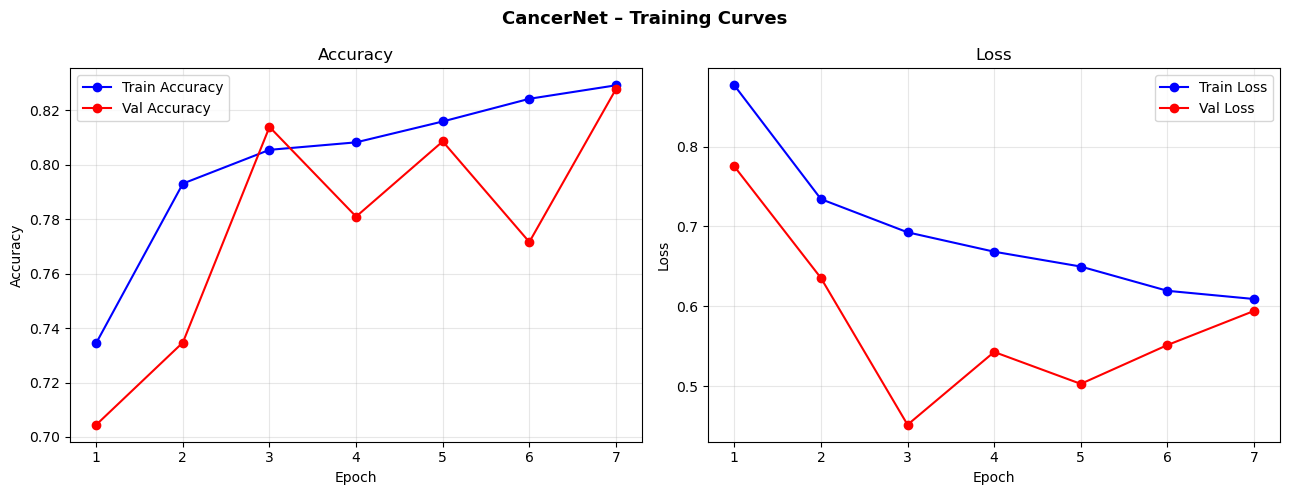

[Saved] training_curves.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("CancerNet – Training Curves", fontsize=13, fontweight='bold')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs_ran, history.history['accuracy'],     'b-o', label='Train Accuracy')
axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Val Accuracy')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history.history['loss'],     'b-o', label='Train Loss')
axes[1].plot(epochs_ran, history.history['val_loss'], 'r-o', label='Val Loss')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] training_curves.png")

#### Confusion Matrix

770/770 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step


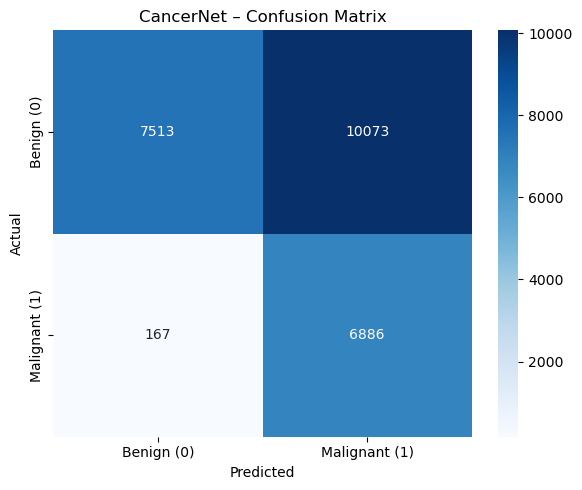

[Saved] confusion_matrix.png

True  Negatives (Benign correct)   : 7513
False Positives (Benign as Malign) : 10073
False Negatives (Missed cancers)   : 167  ← minimise this!
True  Positives (Malign correct)   : 6886

Sensitivity (Recall) : 0.9763
Specificity          : 0.4272


In [15]:
y_pred_prob = model.predict(val_data, steps=len(val_data))
y_pred      = (y_pred_prob.flatten() > 0.4).astype(int)   
y_true      = val_data.classes[:len(y_pred)]               
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("CancerNet – Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] confusion_matrix.png")

# Extract values
TN, FP, FN, TP = cm.ravel()
print(f"\nTrue  Negatives (Benign correct)   : {TN}")
print(f"False Positives (Benign as Malign) : {FP}")
print(f"False Negatives (Missed cancers)   : {FN}  ← minimise this!")
print(f"True  Positives (Malign correct)   : {TP}")
print(f"\nSensitivity (Recall) : {TP/(TP+FN):.4f}")
print(f"Specificity          : {TN/(TN+FP):.4f}")

#### Classification Report

In [17]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred,target_names=['Benign (IDC-)', 'Malignant (IDC+)']))


Classification Report:
                  precision    recall  f1-score   support

   Benign (IDC-)       0.98      0.43      0.59     17586
Malignant (IDC+)       0.41      0.98      0.57      7053

        accuracy                           0.58     24639
       macro avg       0.69      0.70      0.58     24639
    weighted avg       0.81      0.58      0.59     24639



#### Save Model

In [18]:
from tensorflow.keras.models import load_model 
model=load_model("CancerNet_model.h5")
model.save("CancerNet_model.h5")